# Money-Market Rates



- `ref_rates.xlsx`
- `spy_data_daily.xlsx`

The code first looks for each file in a local `data/` folder, then in the notebook's current folder, and finally in `/mnt/data`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

def locate_file(filename):
    candidates = [
        Path("data") / filename,
        Path(filename),
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in the notebook folder or in a data/ subfolder."
    )

ref_path = locate_file("ref_rates.xlsx")
spy_path = locate_file("spy_data_daily.xlsx")

ref = pd.read_excel(ref_path, sheet_name="data")
ref["date"] = pd.to_datetime(ref["date"])
ref = ref.set_index("date").sort_index()

ref.head()

,DTB3,DFF,SOFR
date,,,
2018-01-01,NaN,1.33,NaN
2018-01-02,1.42,1.42,NaN
2018-01-03,1.39,1.42,NaN
2018-01-04,1.39,1.42,NaN
2018-01-05,1.37,1.42,NaN


## 1. Plot the three money-market rate time series

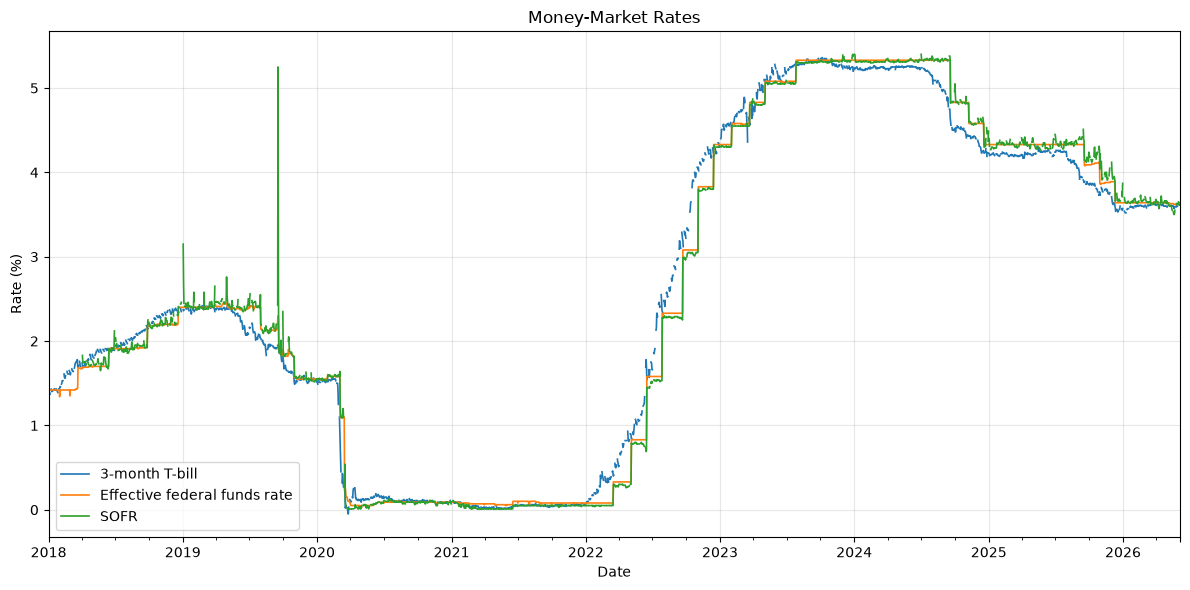

In [2]:
rate_names = {
    "DTB3": "3-month T-bill",
    "DFF": "Effective federal funds rate",
    "SOFR": "SOFR",
}

ax = ref[list(rate_names)].rename(columns=rate_names).plot(
    figsize=(12, 6),
    linewidth=1.2
)
ax.set_title("Money-Market Rates")
ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The three rates move closely together over time because they are all short-term U.S. interest rates.  
The T-bill rate is somewhat more market-driven and can move ahead of changes in administered or overnight rates.

## 2. Correlations in levels and day-over-day differences

The instructions require filtering to dates on which **all three rates are reported**. Therefore, the same complete-case sample is used for both calculations.

In [3]:
rates_common = ref[["DTB3", "DFF", "SOFR"]].dropna()

corr_levels = rates_common.corr()
corr_differences = rates_common.diff().dropna().corr()

print(f"Number of common observations: {len(rates_common):,}")
print("\nCorrelation in levels:")
display(corr_levels.round(4))

print("Correlation in day-over-day changes:")
display(corr_differences.round(4))

Number of common observations: 2,041

Correlation in levels:


,DTB3,DFF,SOFR
DTB3,1.0000,0.9947,0.9929
DFF,0.9947,1.0000,0.9991
SOFR,0.9929,0.9991,1.0000


Correlation in day-over-day changes:


,DTB3,DFF,SOFR
DTB3,1.0000,0.0080,0.0375
DFF,0.0080,1.0000,0.4965
SOFR,0.0375,0.4965,1.0000


### Interpretation

The rate **levels** are extremely highly correlated. This is expected because SOFR, the federal funds rate, and the 3-month T-bill yield are all strongly influenced by the same monetary-policy environment.

The correlations of **daily changes** are much lower. A high correlation in levels does not imply that the rates make identical day-to-day moves. In particular, the T-bill yield is market-priced, while SOFR and the effective federal funds rate are overnight funding rates. Their short-run movements therefore differ even though their long-run levels track one another.

## 3. AR(1) regression for SOFR

Estimate

\[
r_t = \alpha + \beta r_{t-1} + \varepsilon_t.
\]

In [4]:
sofr = ref[["SOFR"]].dropna().copy()
sofr["SOFR_lag"] = sofr["SOFR"].shift(1)
sofr_reg = sofr.dropna()

X_sofr = sm.add_constant(sofr_reg["SOFR_lag"])
sofr_model = sm.OLS(sofr_reg["SOFR"], X_sofr).fit()

alpha_sofr = sofr_model.params["const"]
beta_sofr = sofr_model.params["SOFR_lag"]
r2_sofr = sofr_model.rsquared

print(f"Estimated alpha: {alpha_sofr:.6f}")
print(f"Estimated beta:  {beta_sofr:.6f}")
print(f"R-squared:       {r2_sofr:.6f}")
print(f"Observations:    {int(sofr_model.nobs):,}")

Estimated alpha: 0.004804
Estimated beta:  0.998519
R-squared:       0.997003
Observations:    2,041


In [5]:
print(sofr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   SOFR   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 6.782e+05
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:54:18   Log-Likelihood:                 1668.3
No. Observations:                2041   AIC:                            -3333.
Df Residuals:                    2039   BIC:                            -3321.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      0.004      1.204      0.2

### Interpretation

The estimated regression is approximately

\[
SOFR_t = 0.004804 + 0.998519\,SOFR_{t-1} + \varepsilon_t,
\]

with an \(R^2\) of approximately **0.9970**.

The beta is extremely close to one, so SOFR is highly persistent and has very strong positive autocorrelation in levels. The current rate is therefore very informative about the next period's rate, and a simple forecast for tomorrow is close to today's rate.

However, this does **not** mean that unexpected changes in SOFR are easy to predict. The regression mainly shows that the *level* of the interest rate changes slowly. Its very high persistence is also a warning that regressions involving interest-rate levels can sometimes appear statistically powerful simply because the series are persistent.

## 4. AR(1) regressions for SPY returns and SPY prices

For each series, estimate

\[
y_t = \alpha + \beta y_{t-1} + \varepsilon_t.
\]

In [6]:
spy_returns = pd.read_excel(spy_path, sheet_name="total returns")
spy_prices = pd.read_excel(spy_path, sheet_name="prices")

spy_returns["date"] = pd.to_datetime(spy_returns["date"])
spy_prices["date"] = pd.to_datetime(spy_prices["date"])

spy_returns = spy_returns.set_index("date").sort_index()
spy_prices = spy_prices.set_index("date").sort_index()

def estimate_ar1(series, name):
    data = series.dropna().to_frame(name)
    data[f"{name}_lag"] = data[name].shift(1)
    data = data.dropna()

    X = sm.add_constant(data[f"{name}_lag"])
    model = sm.OLS(data[name], X).fit()

    results = pd.Series(
        {
            "alpha": model.params["const"],
            "beta": model.params[f"{name}_lag"],
            "R-squared": model.rsquared,
            "observations": int(model.nobs),
        },
        name=name,
    )
    return model, results

return_model, return_results = estimate_ar1(spy_returns["SPY"], "SPY return")
price_model, price_results = estimate_ar1(spy_prices["SPY"], "SPY price")

ar1_results = pd.concat([return_results, price_results], axis=1).T
display(ar1_results)

,alpha,beta,R-squared,observations
SPY return,0.000519,-0.082877,0.006869,8164.0
SPY price,-0.016158,1.000590,0.999760,8165.0


In [7]:
print("SPY RETURNS AR(1)")
print(return_model.summary())

print("\nSPY PRICES AR(1)")
print(price_model.summary())

SPY RETURNS AR(1)
                            OLS Regression Results                            
Dep. Variable:             SPY return   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     56.45
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.38e-14
Time:                        21:54:18   Log-Likelihood:                 24669.
No. Observations:                8164   AIC:                        -4.933e+04
Df Residuals:                    8162   BIC:                        -4.932e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0005 

### Interpretation

For **SPY returns**, the estimated beta is approximately **−0.0829** and the \(R^2\) is only about **0.0069**. Thus, daily SPY returns have very weak negative first-order autocorrelation. Yesterday's return explains less than 1% of the variation in today's return, so it has almost no useful forecasting power.

For **SPY prices**, the estimated beta is approximately **1.0006** and the \(R^2\) is about **0.9998**. SPY price levels are therefore extremely autocorrelated: today's price is naturally very close to yesterday's price.

This contrast is fundamental. Asset **price levels** are highly persistent, while **returns** are much closer to unpredictable. A high \(R^2\) in the price regression does not imply an easy profitable trading strategy; it mainly reflects that prices evolve gradually from one day to the next.

## Final answers

1. The three short-term rates move closely together through the monetary-policy cycle.
2. Their levels are almost perfectly correlated, but their daily changes are much less correlated.
3. SOFR is strongly autocorrelated in levels: \(\hat\beta=0.998519\), with \(R^2=0.997003\).
4. SPY returns have very little autocorrelation: \(\hat\beta=-0.082877\), with \(R^2=0.006869\). SPY prices are extremely autocorrelated: \(\hat\beta=1.000590\), with \(R^2=0.999760\).